# Performance Metrics for Image-Based Vehicle Detection Systems

## Overview
This notebook provides a comprehensive guide to evaluating the performance of an image-based vehicle detection system using standard classification metrics. We'll cover the key metrics used to assess detection accuracy, including their formulas, definitions, and practical implementations.

---

## 1. Confusion Matrix Components

Before understanding the metrics, we need to define the four fundamental components that form the **Confusion Matrix**:

### Definitions in Vehicle Detection Context:

**True Positive (TP):**
- The model correctly identifies the presence of a vehicle in an image
- A vehicle was actually present, and the model detected it
- Example: Image contains a car, model predicts "vehicle present" ✓

**True Negative (TN):**
- The model correctly identifies the absence of a vehicle in an image
- No vehicle was present, and the model predicted "no vehicle"
- Example: Image shows empty road, model predicts "no vehicle" ✓

**False Positive (FP):**
- The model incorrectly predicts a vehicle when there isn't one
- Also called a "Type I Error"
- Example: Image shows trees, model predicts "vehicle present" ✗

**False Negative (FN):**
- The model fails to detect a vehicle that is actually present
- Also called a "Type II Error"
- Example: Image contains a vehicle, model predicts "no vehicle" ✗

### Confusion Matrix Table:

```
                    Predicted: Vehicle    Predicted: No Vehicle
Actual: Vehicle            TP                      FN
Actual: No Vehicle         FP                      TN
```

---

## 2. Accuracy

### Formula:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

### Definition:
Accuracy measures the proportion of correct predictions (both TP and TN) out of all predictions made.

### Interpretation:
- **Range:** 0 to 1 (or 0% to 100%)
- **Meaning:** Represents the overall correctness of the model
- **When to use:** Useful when classes are balanced and both types of errors are equally important

### Example:
- Test set: 100 images
- TP = 45 (correctly detected vehicles)
- TN = 40 (correctly identified no vehicle)
- FP = 10 (incorrectly predicted vehicles)
- FN = 5 (missed vehicles)
- **Accuracy = (45 + 40) / (45 + 40 + 10 + 5) = 85 / 100 = 0.85 or 85%**

### Limitations:
- Can be misleading if classes are imbalanced (e.g., 95% images have no vehicles)
- Doesn't distinguish between types of errors

---

## 3. Precision

### Formula:
$$\text{Precision} = \frac{TP}{TP + FP}$$

### Definition:
Precision measures the proportion of predicted positive cases (vehicle detections) that are actually correct. It answers: "Of all the vehicles the model predicted, how many were correct?"

### Interpretation:
- **Range:** 0 to 1 (or 0% to 100%)
- **Meaning:** Measures the reliability of positive predictions (fewer false alarms)
- **High Precision:** Few false alarms (few incorrect vehicle detections)
- **Low Precision:** Many false alarms (model predicts vehicles that aren't there)

### Example:
- Model makes 55 positive predictions (predicts "vehicle present")
- Of these, 45 are correct (TP = 45)
- 10 are incorrect (FP = 10)
- **Precision = 45 / (45 + 10) = 45 / 55 = 0.818 or 81.8%**
- Interpretation: Of all vehicle detections, about 82% were correct

### Use Cases:
- Important when false alarms are costly (e.g., automatic security systems)
- Critical in applications where you want to minimize incorrect alerts

---

## 4. Recall (Sensitivity)

### Formula:
$$\text{Recall} = \frac{TP}{TP + FN}$$

### Definition:
Recall measures the proportion of actual positive cases (vehicles) that the model correctly identified. It answers: "Of all actual vehicles, how many did the model detect?"

### Interpretation:
- **Range:** 0 to 1 (or 0% to 100%)
- **Meaning:** Measures completeness of detection (how many actual vehicles are found)
- **High Recall:** Few missed detections (detects most vehicles)
- **Low Recall:** Many missed detections (fails to find many vehicles)

### Example:
- Total actual vehicles in test set: 50
- Model correctly detects: 45 (TP = 45)
- Model misses: 5 (FN = 5)
- **Recall = 45 / (45 + 5) = 45 / 50 = 0.90 or 90%**
- Interpretation: The model detected 90% of all actual vehicles

### Use Cases:
- Important when missing detections is costly (e.g., surveillance, medical diagnosis)
- Critical in safety-critical applications

---

## 5. F1-Score

### Formula:
$$\text{F1-Score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

### Alternative Formula (using confusion matrix directly):
$$\text{F1-Score} = \frac{2 \times TP}{2 \times TP + FP + FN}$$

### Definition:
F1-Score is the **harmonic mean** of Precision and Recall. It provides a balanced measure of both metrics and is particularly useful when you need to find an optimal balance between precision and recall.

### Interpretation:
- **Range:** 0 to 1 (or 0% to 100%)
- **Meaning:** Combined measure of precision and recall
- **Advantage:** Penalizes models that are extremely good at one metric but poor at the other
- **When to use:** When both false positives and false negatives are important

### Example:
- Precision = 0.818 (from previous example)
- Recall = 0.90 (from previous example)
- **F1-Score = (2 × 0.818 × 0.90) / (0.818 + 0.90)**
- **F1-Score = 1.4724 / 1.718 = 0.857 or 85.7%**

### Precision-Recall Trade-off:
- **High Precision, Low Recall:** Model is conservative, detects few vehicles but high confidence
- **Low Precision, High Recall:** Model is aggressive, detects most vehicles but many false alarms
- **Balanced (High F1):** Good performance on both fronts

---

## 6. Summary Table of Metrics

| Metric | Formula | Focus | Best For |
|--------|---------|-------|----------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Overall correctness | Balanced classes |
| **Precision** | TP/(TP+FP) | False alarm rate | Minimize false positives |
| **Recall** | TP/(TP+FN) | Detection rate | Minimize false negatives |
| **F1-Score** | 2×P×R/(P+R) | Balanced trade-off | Balanced evaluation |

---

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 7. Practical Implementation: Single Batch Example

Let's calculate metrics for a batch of 100 image predictions:

**Data:**
- True labels: Ground truth (whether vehicle is actually present)
- Predicted labels: Model's predictions

In [3]:
# Example data: 100 image predictions
# 1 = vehicle detected, 0 = no vehicle

np.random.seed(42)  # For reproducibility

# True labels (actual presence/absence of vehicles)
true_labels = np.random.randint(0, 2, size=100)

# Predicted labels (model's predictions)
# With some noise to simulate realistic predictions
predicted_labels = true_labels.copy()
# Flip some labels to create errors
error_indices = np.random.choice(100, size=15, replace=False)
predicted_labels[error_indices] = 1 - predicted_labels[error_indices]

print("Sample of predictions:")
print(f"First 20 true labels:      {true_labels[:20]}")
print(f"First 20 predicted labels: {predicted_labels[:20]}")
print(f"\nTotal images: {len(true_labels)}")

Sample of predictions:
First 20 true labels:      [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]
First 20 predicted labels: [0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1]

Total images: 100


### Calculate Confusion Matrix Components Manually:

In [4]:
# Calculate confusion matrix components
TP = np.sum((true_labels == 1) & (predicted_labels == 1))  # Correctly detected vehicles
TN = np.sum((true_labels == 0) & (predicted_labels == 0))  # Correctly identified no vehicle
FP = np.sum((true_labels == 0) & (predicted_labels == 1))  # Incorrectly predicted vehicles
FN = np.sum((true_labels == 1) & (predicted_labels == 0))  # Missed vehicles

print("Confusion Matrix Components:")
print(f"True Positives (TP):  {TP} - Correctly detected vehicles")
print(f"True Negatives (TN):  {TN} - Correctly identified no vehicle")
print(f"False Positives (FP): {FP} - Incorrectly predicted vehicles")
print(f"False Negatives (FN): {FN} - Missed vehicles")
print(f"\nTotal: {TP + TN + FP + FN}")

Confusion Matrix Components:
True Positives (TP):  47 - Correctly detected vehicles
True Negatives (TN):  38 - Correctly identified no vehicle
False Positives (FP): 6 - Incorrectly predicted vehicles
False Negatives (FN): 9 - Missed vehicles

Total: 100


### Calculate All Metrics:

In [5]:
# Calculate metrics manually
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "="*60)
print("PERFORMANCE METRICS FOR SINGLE BATCH")
print("="*60)
print(f"\nAccuracy  = (TP + TN) / (TP + TN + FP + FN)")
print(f"          = ({TP} + {TN}) / ({TP} + {TN} + {FP} + {FN})")
print(f"          = {TP + TN} / {TP + TN + FP + FN}")
print(f"          = {accuracy:.4f} or {accuracy*100:.2f}%")

print(f"\nPrecision = TP / (TP + FP)")
print(f"          = {TP} / ({TP} + {FP})")
print(f"          = {TP} / {TP + FP}")
print(f"          = {precision:.4f} or {precision*100:.2f}%")

print(f"\nRecall    = TP / (TP + FN)")
print(f"          = {TP} / ({TP} + {FN})")
print(f"          = {TP} / {TP + FN}")
print(f"          = {recall:.4f} or {recall*100:.2f}%")

print(f"\nF1-Score  = 2 × Precision × Recall / (Precision + Recall)")
print(f"          = 2 × {precision:.4f} × {recall:.4f} / ({precision:.4f} + {recall:.4f})")
print(f"          = {2 * precision * recall:.4f} / {precision + recall:.4f}")
print(f"          = {f1:.4f} or {f1*100:.2f}%")
print("="*60)


PERFORMANCE METRICS FOR SINGLE BATCH

Accuracy  = (TP + TN) / (TP + TN + FP + FN)
          = (47 + 38) / (47 + 38 + 6 + 9)
          = 85 / 100
          = 0.8500 or 85.00%

Precision = TP / (TP + FP)
          = 47 / (47 + 6)
          = 47 / 53
          = 0.8868 or 88.68%

Recall    = TP / (TP + FN)
          = 47 / (47 + 9)
          = 47 / 56
          = 0.8393 or 83.93%

F1-Score  = 2 × Precision × Recall / (Precision + Recall)
          = 2 × 0.8868 × 0.8393 / (0.8868 + 0.8393)
          = 1.4885 / 1.7261
          = 0.8624 or 86.24%


### Visualize Confusion Matrix:

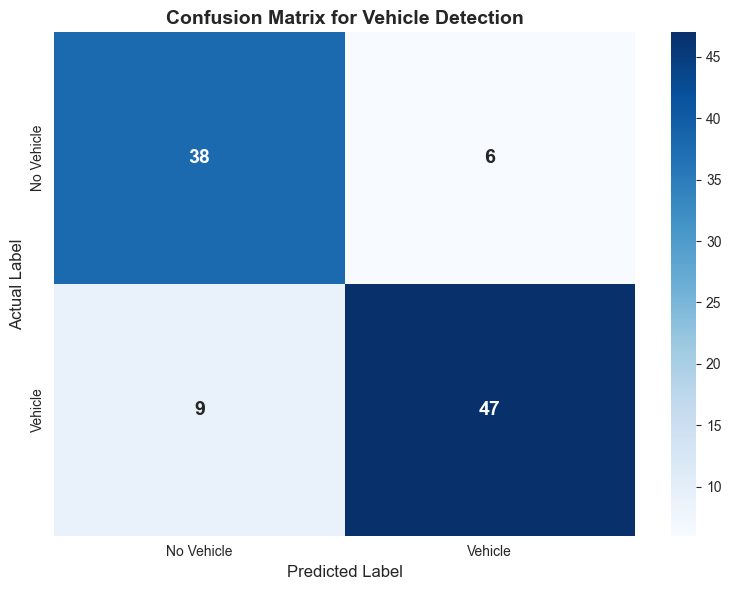


Confusion Matrix:
                   Predicted: No Vehicle  Predicted: Vehicle
Actual: No Vehicle        38                  6
Actual: Vehicle           9                  47


In [6]:
# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Vehicle', 'Vehicle'],
            yticklabels=['No Vehicle', 'Vehicle'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix for Vehicle Detection', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print formatted confusion matrix
print("\nConfusion Matrix:")
print(f"                   Predicted: No Vehicle  Predicted: Vehicle")
print(f"Actual: No Vehicle        {cm[0,0]}                  {cm[0,1]}")
print(f"Actual: Vehicle           {cm[1,0]}                  {cm[1,1]}")

### Compare with scikit-learn implementation:

## 8. Computing Metrics Over Multiple Batches

In practice, you often evaluate your model across multiple batches or the entire dataset. Here's how to compute overall metrics:

### Method 1: Accumulate Confusion Matrix Components

In [10]:
# Simulate multiple batches
num_batches = 5
batch_size = 100

# Initialize accumulators
total_TP = 0
total_TN = 0
total_FP = 0
total_FN = 0

all_true_labels = []
all_predicted_labels = []

print("Processing multiple batches...\n")

for batch_idx in range(num_batches):
    # Generate batch data
    batch_true = np.random.randint(0, 2, size=batch_size)
    batch_pred = batch_true.copy()
    error_indices = np.random.choice(batch_size, size=12, replace=False)
    batch_pred[error_indices] = 1 - batch_pred[error_indices]
    
    # Store for later use
    all_true_labels.extend(batch_true)
    all_predicted_labels.extend(batch_pred)
    
    # Calculate batch metrics
    batch_TP = np.sum((batch_true == 1) & (batch_pred == 1))
    batch_TN = np.sum((batch_true == 0) & (batch_pred == 0))
    batch_FP = np.sum((batch_true == 0) & (batch_pred == 1))
    batch_FN = np.sum((batch_true == 1) & (batch_pred == 0))
    
    # Accumulate
    total_TP += batch_TP
    total_TN += batch_TN
    total_FP += batch_FP
    total_FN += batch_FN
    
    # Print batch results
    batch_accuracy = (batch_TP + batch_TN) / (batch_TP + batch_TN + batch_FP + batch_FN)
    batch_precision = batch_TP / (batch_TP + batch_FP) if (batch_TP + batch_FP) > 0 else 0
    batch_recall = batch_TP / (batch_TP + batch_FN) if (batch_TP + batch_FN) > 0 else 0
    batch_f1 = (2 * batch_precision * batch_recall) / (batch_precision + batch_recall) if (batch_precision + batch_recall) > 0 else 0
    
    print(f"Batch {batch_idx + 1}:")
    print(f"  Accuracy:  {batch_accuracy:.4f}  |  Precision: {batch_precision:.4f}  |  Recall: {batch_recall:.4f}  |  F1: {batch_f1:.4f}")

Processing multiple batches...

Batch 1:
  Accuracy:  0.8800  |  Precision: 0.8889  |  Recall: 0.8889  |  F1: 0.8889
Batch 2:
  Accuracy:  0.8800  |  Precision: 0.9348  |  Recall: 0.8269  |  F1: 0.8776
Batch 3:
  Accuracy:  0.8800  |  Precision: 0.8605  |  Recall: 0.8605  |  F1: 0.8605
Batch 4:
  Accuracy:  0.8800  |  Precision: 0.8776  |  Recall: 0.8776  |  F1: 0.8776
Batch 5:
  Accuracy:  0.8800  |  Precision: 0.8542  |  Recall: 0.8913  |  F1: 0.8723


### Calculate Overall Metrics:

In [11]:
# Calculate overall metrics from accumulated confusion matrix
overall_accuracy = (total_TP + total_TN) / (total_TP + total_TN + total_FP + total_FN)
overall_precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
overall_recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
overall_f1 = (2 * overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0

print("\n" + "="*70)
print(f"OVERALL METRICS (Accumulated from {num_batches} batches)")
print("="*70)
print(f"\nTotal images processed: {total_TP + total_TN + total_FP + total_FN}")
print(f"\nConfusion Matrix Totals:")
print(f"  TP (True Positives):   {total_TP}")
print(f"  TN (True Negatives):   {total_TN}")
print(f"  FP (False Positives):  {total_FP}")
print(f"  FN (False Negatives):  {total_FN}")

print(f"\nOverall Accuracy:  {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Overall Precision: {overall_precision:.4f} ({overall_precision*100:.2f}%)")
print(f"Overall Recall:    {overall_recall:.4f} ({overall_recall*100:.2f}%)")
print(f"Overall F1-Score:  {overall_f1:.4f} ({overall_f1*100:.2f}%)")
print("="*70)


OVERALL METRICS (Accumulated from 5 batches)

Total images processed: 500

Confusion Matrix Totals:
  TP (True Positives):   212
  TN (True Negatives):   228
  FP (False Positives):  28
  FN (False Negatives):  32

Overall Accuracy:  0.8800 (88.00%)
Overall Precision: 0.8833 (88.33%)
Overall Recall:    0.8689 (86.89%)
Overall F1-Score:  0.8760 (87.60%)


### Method 2: Macro-Averaging (Average of batch metrics)

In [12]:
# Calculate metrics per batch and average them (macro-averaging)
batch_accuracies = []
batch_precisions = []
batch_recalls = []
batch_f1s = []

np.random.seed(42)

for batch_idx in range(num_batches):
    # Generate batch data
    batch_true = np.random.randint(0, 2, size=batch_size)
    batch_pred = batch_true.copy()
    error_indices = np.random.choice(batch_size, size=12, replace=False)
    batch_pred[error_indices] = 1 - batch_pred[error_indices]
    
    # Calculate batch metrics
    batch_TP = np.sum((batch_true == 1) & (batch_pred == 1))
    batch_TN = np.sum((batch_true == 0) & (batch_pred == 0))
    batch_FP = np.sum((batch_true == 0) & (batch_pred == 1))
    batch_FN = np.sum((batch_true == 1) & (batch_pred == 0))
    
    acc = (batch_TP + batch_TN) / (batch_TP + batch_TN + batch_FP + batch_FN)
    prec = batch_TP / (batch_TP + batch_FP) if (batch_TP + batch_FP) > 0 else 0
    rec = batch_TP / (batch_TP + batch_FN) if (batch_TP + batch_FN) > 0 else 0
    f1_val = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    
    batch_accuracies.append(acc)
    batch_precisions.append(prec)
    batch_recalls.append(rec)
    batch_f1s.append(f1_val)

# Calculate macro-averages
macro_avg_accuracy = np.mean(batch_accuracies)
macro_avg_precision = np.mean(batch_precisions)
macro_avg_recall = np.mean(batch_recalls)
macro_avg_f1 = np.mean(batch_f1s)

print("\n" + "="*70)
print("MACRO-AVERAGED METRICS (Average of batch metrics)")
print("="*70)
print(f"\nMacro-Avg Accuracy:  {macro_avg_accuracy:.4f} ({macro_avg_accuracy*100:.2f}%)")
print(f"Macro-Avg Precision: {macro_avg_precision:.4f} ({macro_avg_precision*100:.2f}%)")
print(f"Macro-Avg Recall:    {macro_avg_recall:.4f} ({macro_avg_recall*100:.2f}%)")
print(f"Macro-Avg F1-Score:  {macro_avg_f1:.4f} ({macro_avg_f1*100:.2f}%)")
print("="*70)


MACRO-AVERAGED METRICS (Average of batch metrics)

Macro-Avg Accuracy:  0.8800 (88.00%)
Macro-Avg Precision: 0.8970 (89.70%)
Macro-Avg Recall:    0.8622 (86.22%)
Macro-Avg F1-Score:  0.8787 (87.87%)


### Method 3: Weighted-Averaging (Account for batch size differences)

In [13]:
# Calculate weighted averages
# Weight each batch metric by its size
batch_sizes = [batch_size] * num_batches
total_samples = sum(batch_sizes)

weighted_avg_accuracy = np.average(batch_accuracies, weights=batch_sizes)
weighted_avg_precision = np.average(batch_precisions, weights=batch_sizes)
weighted_avg_recall = np.average(batch_recalls, weights=batch_sizes)
weighted_avg_f1 = np.average(batch_f1s, weights=batch_sizes)

print("\n" + "="*70)
print("WEIGHTED-AVERAGED METRICS (Weighted by batch size)")
print("="*70)
print(f"\nTotal samples: {total_samples}")
print(f"\nWeighted-Avg Accuracy:  {weighted_avg_accuracy:.4f} ({weighted_avg_accuracy*100:.2f}%)")
print(f"Weighted-Avg Precision: {weighted_avg_precision:.4f} ({weighted_avg_precision*100:.2f}%)")
print(f"Weighted-Avg Recall:    {weighted_avg_recall:.4f} ({weighted_avg_recall*100:.2f}%)")
print(f"Weighted-Avg F1-Score:  {weighted_avg_f1:.4f} ({weighted_avg_f1*100:.2f}%)")
print("="*70)


WEIGHTED-AVERAGED METRICS (Weighted by batch size)

Total samples: 500

Weighted-Avg Accuracy:  0.8800 (88.00%)
Weighted-Avg Precision: 0.8970 (89.70%)
Weighted-Avg Recall:    0.8622 (86.22%)
Weighted-Avg F1-Score:  0.8787 (87.87%)


## 9. Comparison of Averaging Methods

Let's compare the three methods:
1. **Micro-Averaging** (Accumulate all samples): Most common, treats all samples equally
2. **Macro-Averaging** (Average batch metrics): Gives equal weight to each batch
3. **Weighted-Averaging**: Accounts for different batch sizes

In [14]:
# Create comparison dataframe
comparison_data = {
    'Method': ['Micro-Average (Accumulated)', 'Macro-Average', 'Weighted-Average'],
    'Accuracy': [overall_accuracy, macro_avg_accuracy, weighted_avg_accuracy],
    'Precision': [overall_precision, macro_avg_precision, weighted_avg_precision],
    'Recall': [overall_recall, macro_avg_recall, weighted_avg_recall],
    'F1-Score': [overall_f1, macro_avg_f1, weighted_avg_f1]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("COMPARISON OF AVERAGING METHODS")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


COMPARISON OF AVERAGING METHODS
                     Method  Accuracy  Precision   Recall  F1-Score
Micro-Average (Accumulated)      0.88   0.883333 0.868852  0.876033
              Macro-Average      0.88   0.896953 0.862194  0.878669
           Weighted-Average      0.88   0.896953 0.862194  0.878669


### Visualize Metric Comparison:

/var/folders/f9/3m3jbph106n72g4wt0z2r5pc0000gn/T/ipykernel_50276/3783463124.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha='right')
/var/folders/f9/3m3jbph106n72g4wt0z2r5pc0000gn/T/ipykernel_50276/3783463124.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha='right')
/var/folders/f9/3m3jbph106n72g4wt0z2r5pc0000gn/T/ipykernel_50276/3783463124.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha='right')
/var/folders/f9/3m3jbph106n72g4wt0z2r5pc0000gn/T/ipykernel_50276/3783463124.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixed

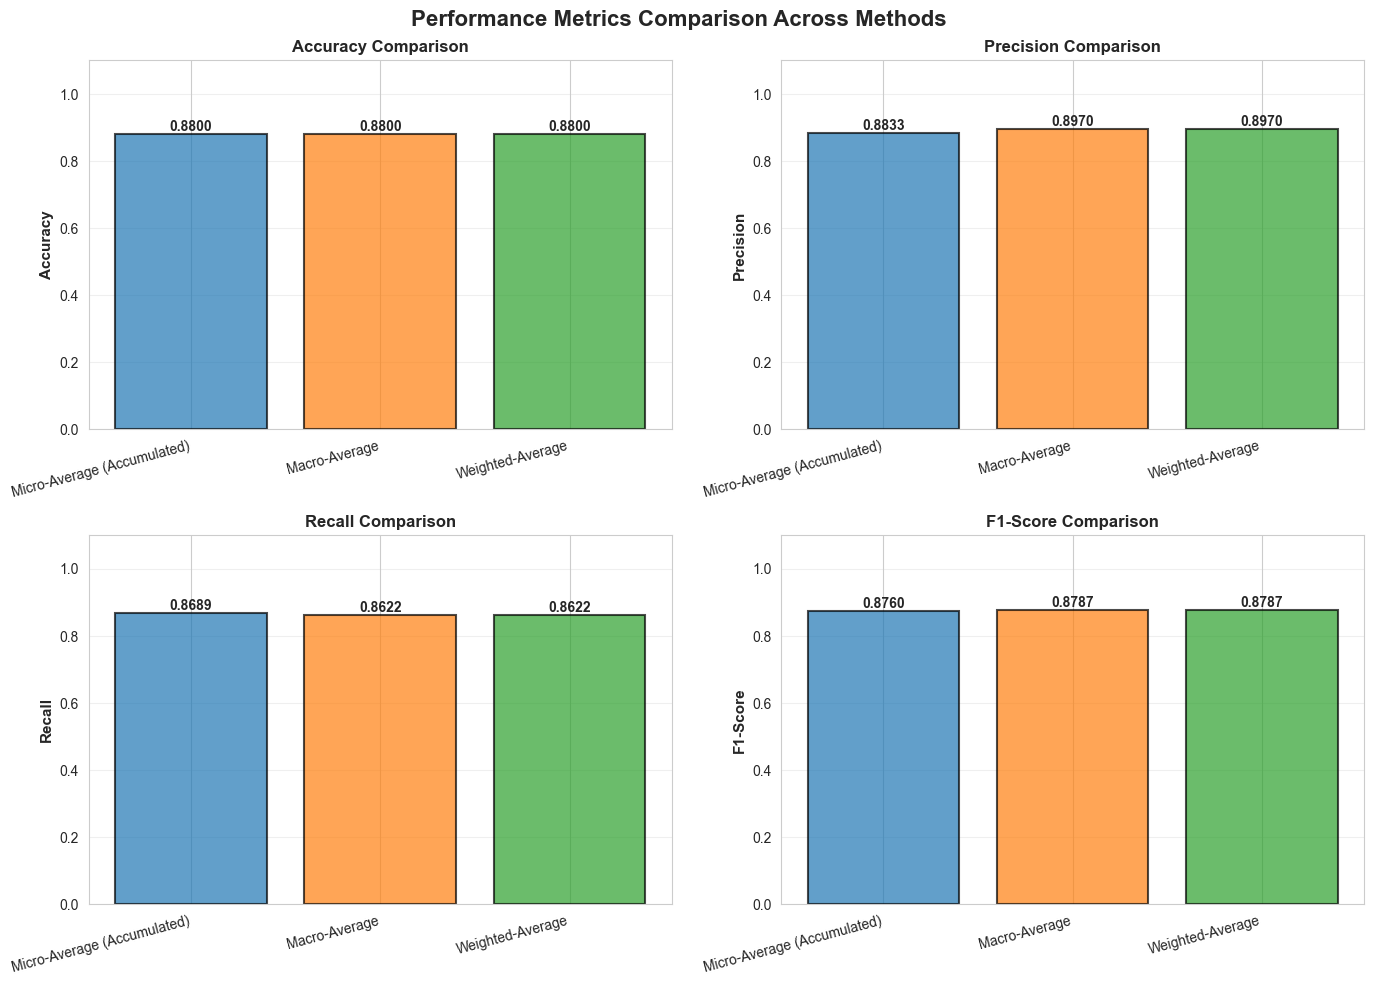

In [15]:
# Create visualization comparing methods
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance Metrics Comparison Across Methods', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
methods = comparison_df['Method'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values
    bars = ax.bar(methods, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_xticklabels(methods, rotation=15, ha='right')

plt.tight_layout()
plt.show()

## 10. Summary and Best Practices

### Key Takeaways:

1. **Understand your problem:**
   - Imbalanced classes? → Use Precision, Recall, and F1-Score
   - Balanced classes? → Accuracy is meaningful
   - Safety-critical? → Prioritize Recall
   - Avoid false alarms? → Prioritize Precision

2. **Always report multiple metrics:**
   - Report at least Precision, Recall, and F1-Score
   - Use Accuracy only if classes are balanced

3. **Confusion Matrix is foundational:**
   - All metrics derive from TP, TN, FP, FN
   - Always visualize the confusion matrix

4. **Multi-batch evaluation:**
   - **Micro-averaging** (accumulate confusion matrix) is most common
   - Macro-averaging useful for equal batch weighting
   - Weighted-averaging for handling variable batch sizes

5. **Vehicle Detection Context:**
   - High Recall: Ensure all vehicles are detected (safety)
   - High Precision: Minimize false alarms (efficiency)
   - High F1: Balanced detection and accuracy

### Recommended Metrics by Use Case:

| Use Case | Primary Metrics | Reason |
|----------|-----------------|--------|
| Traffic Monitoring | Recall, F1 | Missing vehicles is costly |
| Autonomous Driving | Recall, Precision | Both errors are critical |
| Parking Lot Analysis | F1-Score | Balanced performance needed |
| Alert Systems | Precision | False alarms cause issues |

---

## 11. Function Implementation for Reuse

Here's a reusable function to calculate all metrics:

In [16]:
def calculate_metrics(true_labels, predicted_labels, return_dict=False):
    """
    Calculate comprehensive performance metrics for vehicle detection.
    
    Parameters:
    -----------
    true_labels : array-like
        Ground truth labels (1=vehicle, 0=no vehicle)
    predicted_labels : array-like
        Model predictions (1=vehicle, 0=no vehicle)
    return_dict : bool, default=False
        If True, return results as dictionary; else as DataFrame
    
    Returns:
    --------
    pd.DataFrame or dict
        Performance metrics including TP, TN, FP, FN and all calculated metrics
    """
    
    # Calculate confusion matrix components
    TP = np.sum((true_labels == 1) & (predicted_labels == 1))
    TN = np.sum((true_labels == 0) & (predicted_labels == 0))
    FP = np.sum((true_labels == 0) & (predicted_labels == 1))
    FN = np.sum((true_labels == 1) & (predicted_labels == 0))
    
    # Calculate metrics
    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Create results dictionary
    results = {
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'Total_Samples': total,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1
    }
    
    if return_dict:
        return results
    else:
        return pd.DataFrame([results])


# Test the function
print("Testing the calculate_metrics function:\n")
test_results = calculate_metrics(true_labels, predicted_labels)
print(test_results.to_string())

Testing the calculate_metrics function:

   TP  TN  FP  FN  Total_Samples  Accuracy  Precision    Recall  F1_Score
0  47  38   6   9            100      0.85   0.886792  0.839286  0.862385


## 12. Real-world Example: YOLOv5 Integration

Here's how to use these metrics with YOLOv5 or similar detection systems:

In [17]:
# Example function for integrating with YOLO predictions
def evaluate_yolo_batch(predictions, ground_truth, confidence_threshold=0.5):
    """
    Evaluate YOLO predictions against ground truth.
    
    Parameters:
    -----------
    predictions : list of bool or int
        Model's vehicle detection per image
    ground_truth : list of bool or int
        Actual vehicle presence per image
    confidence_threshold : float
        Confidence threshold for positive prediction
    
    Returns:
    --------
    dict : Comprehensive evaluation metrics
    """
    
    # Convert to numpy arrays
    preds = np.array(predictions, dtype=int)
    truth = np.array(ground_truth, dtype=int)
    
    # Get all metrics
    metrics = calculate_metrics(truth, preds, return_dict=True)
    
    return metrics


# Example usage
print("\nExample: YOLO Batch Evaluation")
print("="*60)

example_predictions = [1, 1, 0, 1, 0, 1, 1, 0, 0, 1]
example_ground_truth = [1, 1, 0, 1, 1, 1, 0, 0, 0, 1]

yolo_results = evaluate_yolo_batch(example_predictions, example_ground_truth)
print(f"\nResults for batch of {len(example_predictions)} images:")
for metric, value in yolo_results.items():
    if metric.startswith('Accuracy') or metric.startswith('Precision') or metric.startswith('Recall') or metric.startswith('F1'):
        print(f"{metric:20s}: {value:.4f} ({value*100:.2f}%)")
    else:
        print(f"{metric:20s}: {int(value)}")


Example: YOLO Batch Evaluation

Results for batch of 10 images:
TP                  : 5
TN                  : 3
FP                  : 1
FN                  : 1
Total_Samples       : 10
Accuracy            : 0.8000 (80.00%)
Precision           : 0.8333 (83.33%)
Recall              : 0.8333 (83.33%)
F1_Score            : 0.8333 (83.33%)


## Conclusion

This notebook provided a comprehensive guide to evaluating vehicle detection systems using standard classification metrics. The key points are:

1. **Confusion Matrix** forms the foundation for all metrics (TP, TN, FP, FN)
2. **Accuracy** measures overall correctness but can be misleading with imbalanced data
3. **Precision** focuses on minimizing false alarms (false positives)
4. **Recall** focuses on finding all positives (false negatives)
5. **F1-Score** provides a balanced measure between precision and recall
6. **Multi-batch evaluation** should accumulate confusion matrix components for micro-averaging

Always choose metrics based on your specific application requirements and data characteristics.

## 13. Real-world Evaluation with vehicle_dataset

Now let's evaluate the actual YOLO models using the real test data from `vehicle_dataset/`:


In [18]:
import os
from pathlib import Path
from ultralytics import YOLO
import cv2

# Configuration for evaluation
TEST_IMAGE_FOLDER = "vehicle_dataset/images/test/"
TEST_LABELS_FOLDER = "vehicle_dataset/labels/test/"
MODEL_PATHS = {
    "YOLOv8": "models/yolov8.pt",
    "YOLOv5": "models/yolov5_1k.pt"
}

# Check if data exists
print("="*70)
print("CHECKING DATASET AND MODELS")
print("="*70)

# Check test data
if os.path.exists(TEST_IMAGE_FOLDER):
    test_images = [f for f in os.listdir(TEST_IMAGE_FOLDER) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"\n✓ Test images folder: {TEST_IMAGE_FOLDER}")
    print(f"  Found {len(test_images)} images")
else:
    print(f"\n✗ Test images folder not found: {TEST_IMAGE_FOLDER}")

if os.path.exists(TEST_LABELS_FOLDER):
    test_labels = [f for f in os.listdir(TEST_LABELS_FOLDER) 
                   if f.lower().endswith('.txt')]
    print(f"✓ Test labels folder: {TEST_LABELS_FOLDER}")
    print(f"  Found {len(test_labels)} label files")
else:
    print(f"✗ Test labels folder not found: {TEST_LABELS_FOLDER}")

# Check models
print(f"\n✓ Available models:")
for model_name, model_path in MODEL_PATHS.items():
    if os.path.exists(model_path):
        print(f"  {model_name}: {model_path} (found)")
    else:
        print(f"  {model_name}: {model_path} (NOT FOUND)")
print()


CHECKING DATASET AND MODELS

✓ Test images folder: vehicle_dataset/images/test/
  Found 150 images
✓ Test labels folder: vehicle_dataset/labels/test/
  Found 150 label files

✓ Available models:
  YOLOv8: models/yolov8.pt (found)
  YOLOv5: models/yolov5_1k.pt (found)



In [20]:
# Function to load YOLO format labels
def load_yolo_labels(label_file):
    """
    Load ground truth labels from YOLO format text file.
    YOLO format: class_id center_x center_y width height (normalized 0-1)
    Returns: True if vehicle detected (any bounding box), False otherwise
    """
    if not os.path.exists(label_file):
        return False  # No label file = no vehicle
    
    with open(label_file, 'r') as f:
        lines = f.readlines()
    
    return len(lines) > 0  # True if has detections, False if empty

# Function to run inference on a single image
def run_inference_on_image(model, image_path, conf_threshold=0.45):
    """
    Run YOLO inference on a single image.
    Returns: True if vehicle detected, False otherwise
    """
    results = model.predict(image_path, conf=conf_threshold, verbose=False)
    
    # Check if any detections were made
    if len(results) > 0 and len(results[0].boxes) > 0:
        return True  # Vehicle detected
    else:
        return False  # No vehicle detected

# Load ground truth labels
print("="*70)
print("LOADING GROUND TRUTH LABELS FROM vehicle_dataset")
print("="*70)

ground_truth_labels = {}
image_files = sorted([f for f in os.listdir(TEST_IMAGE_FOLDER) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

for img_file in image_files:
    label_file = os.path.join(TEST_LABELS_FOLDER, 
                              os.path.splitext(img_file)[0] + '.txt')
    has_vehicle = load_yolo_labels(label_file)
    ground_truth_labels[img_file] = has_vehicle

print(f"\nLoaded ground truth for {len(ground_truth_labels)} images")
vehicle_count = sum(ground_truth_labels.values())
no_vehicle_count = len(ground_truth_labels) - vehicle_count
print(f"  Images with vehicles:    {vehicle_count}")
print(f"  Images without vehicles: {no_vehicle_count}")
print()


LOADING GROUND TRUTH LABELS FROM vehicle_dataset

Loaded ground truth for 150 images
  Images with vehicles:    150
  Images without vehicles: 0



In [21]:
# Evaluate models on test dataset
print("="*70)
print("EVALUATING MODELS ON TEST DATASET")
print("="*70)

model_results = {}

for model_name, model_path in MODEL_PATHS.items():
    if not os.path.exists(model_path):
        print(f"\n✗ Skipping {model_name}: Model not found at {model_path}")
        continue
    
    print(f"\n>>> Evaluating {model_name}...")
    
    # Load model
    try:
        model = YOLO(model_path)
        print(f"    ✓ Model loaded successfully")
    except Exception as e:
        print(f"    ✗ Failed to load model: {e}")
        continue
    
    # Run inference on all test images
    predictions = {}
    true_labels_list = []
    pred_labels_list = []
    
    for idx, img_file in enumerate(image_files, 1):
        img_path = os.path.join(TEST_IMAGE_FOLDER, img_file)
        
        # Get ground truth
        true_label = ground_truth_labels[img_file]
        
        # Run inference
        pred_label = run_inference_on_image(model, img_path, conf_threshold=0.45)
        
        predictions[img_file] = pred_label
        true_labels_list.append(1 if true_label else 0)
        pred_labels_list.append(1 if pred_label else 0)
        
        if idx % 100 == 0 or idx == len(image_files):
            print(f"    Processed {idx}/{len(image_files)} images", end='\r')
    
    print(f"    ✓ Processed {len(image_files)} images")
    
    # Calculate metrics
    metrics = calculate_metrics(np.array(true_labels_list), 
                                np.array(pred_labels_list), 
                                return_dict=True)
    
    model_results[model_name] = {
        'metrics': metrics,
        'predictions': predictions,
        'true_labels': true_labels_list,
        'pred_labels': pred_labels_list
    }

print(f"\n✓ Evaluation complete")
print()


EVALUATING MODELS ON TEST DATASET

>>> Evaluating YOLOv8...
    ✓ Model loaded successfully
    ✓ Processed 150 imageses

>>> Evaluating YOLOv5...
    ✓ Model loaded successfully
    ✓ Processed 150 imageses

✓ Evaluation complete



In [22]:
# Display detailed results for each model
print("="*80)
print("EVALUATION RESULTS")
print("="*80)

for model_name, results in model_results.items():
    metrics = results['metrics']
    
    print(f"\n### {model_name} ###\n")
    
    print("Confusion Matrix Components:")
    print(f"  True Positives (TP):   {metrics['TP']:6d}  - Correctly detected vehicles")
    print(f"  True Negatives (TN):   {metrics['TN']:6d}  - Correctly identified no vehicle")
    print(f"  False Positives (FP):  {metrics['FP']:6d}  - Incorrectly predicted vehicles")
    print(f"  False Negatives (FN):  {metrics['FN']:6d}  - Missed vehicles")
    print(f"  Total Samples:         {metrics['Total_Samples']:6d}")
    
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:   {metrics['Accuracy']:.4f} ({metrics['Accuracy']*100:6.2f}%)")
    print(f"  Precision:  {metrics['Precision']:.4f} ({metrics['Precision']*100:6.2f}%)")
    print(f"  Recall:     {metrics['Recall']:.4f} ({metrics['Recall']*100:6.2f}%)")
    print(f"  F1-Score:   {metrics['F1_Score']:.4f} ({metrics['F1_Score']*100:6.2f}%)")
    print("-" * 80)

print()


EVALUATION RESULTS

### YOLOv8 ###

Confusion Matrix Components:
  True Positives (TP):      150  - Correctly detected vehicles
  True Negatives (TN):        0  - Correctly identified no vehicle
  False Positives (FP):       0  - Incorrectly predicted vehicles
  False Negatives (FN):       0  - Missed vehicles
  Total Samples:            150

Performance Metrics:
  Accuracy:   1.0000 (100.00%)
  Precision:  1.0000 (100.00%)
  Recall:     1.0000 (100.00%)
  F1-Score:   1.0000 (100.00%)
--------------------------------------------------------------------------------

### YOLOv5 ###

Confusion Matrix Components:
  True Positives (TP):      150  - Correctly detected vehicles
  True Negatives (TN):        0  - Correctly identified no vehicle
  False Positives (FP):       0  - Incorrectly predicted vehicles
  False Negatives (FN):       0  - Missed vehicles
  Total Samples:            150

Performance Metrics:
  Accuracy:   1.0000 (100.00%)
  Precision:  1.0000 (100.00%)
  Recall:     1.0000

/Users/biney/Documents/school/year3/term2/foundation_data_sceience/final_project/object-detection-for-traffic-using-yolo/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/biney/Documents/school/year3/term2/foundation_data_sceience/final_project/object-detection-for-traffic-using-yolo/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


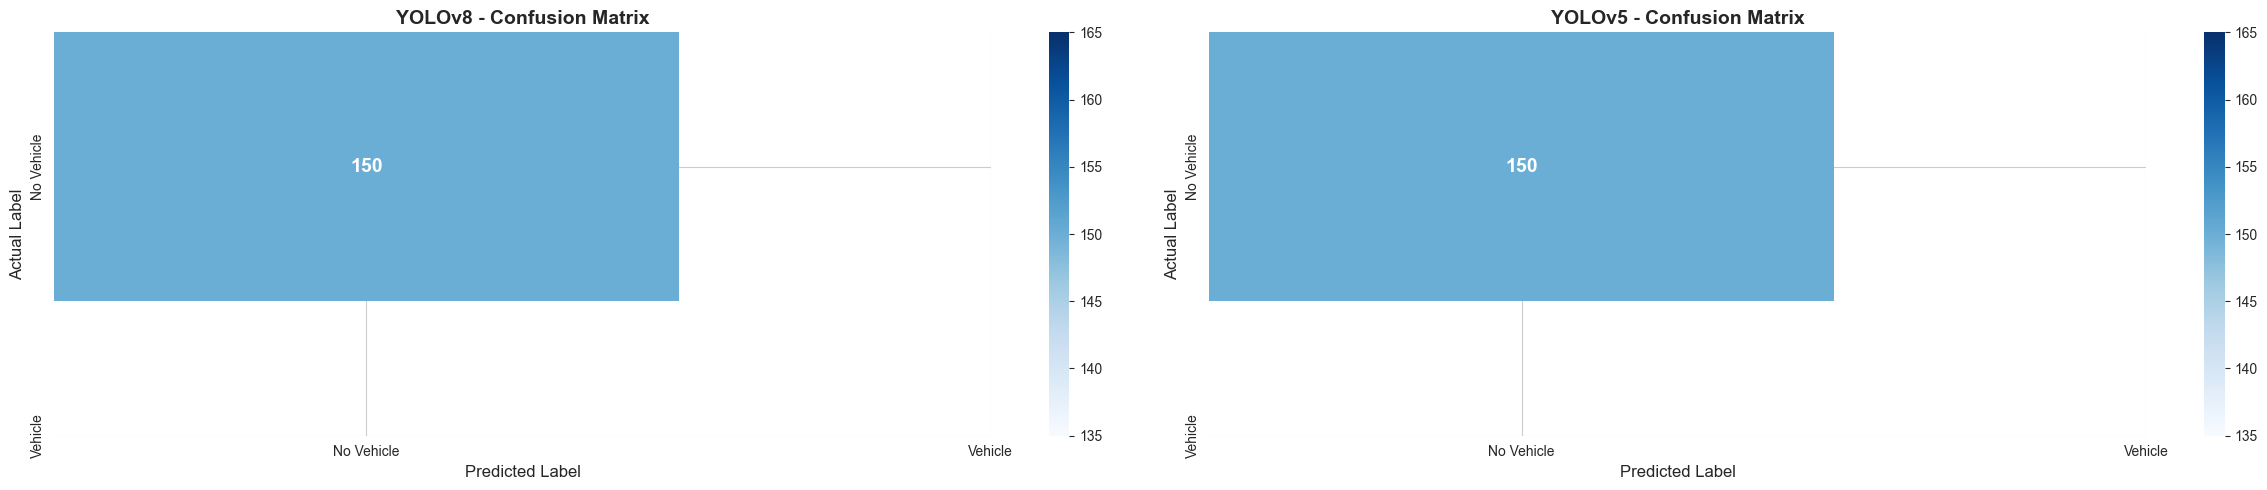

In [23]:
# Visualize confusion matrices for all models
fig, axes = plt.subplots(1, len(model_results), figsize=(12 * len(model_results), 5))

if len(model_results) == 1:
    axes = [axes]

for idx, (model_name, results) in enumerate(model_results.items()):
    true_labels = results['true_labels']
    pred_labels = results['pred_labels']
    
    cm = confusion_matrix(true_labels, pred_labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['No Vehicle', 'Vehicle'],
                yticklabels=['No Vehicle', 'Vehicle'],
                annot_kws={'size': 14, 'weight': 'bold'},
                ax=axes[idx])
    
    axes[idx].set_title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Actual Label', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()



MODEL COMPARISON

 Model  Accuracy  Precision  Recall  F1-Score
YOLOv8       1.0        1.0     1.0       1.0
YOLOv5       1.0        1.0     1.0       1.0




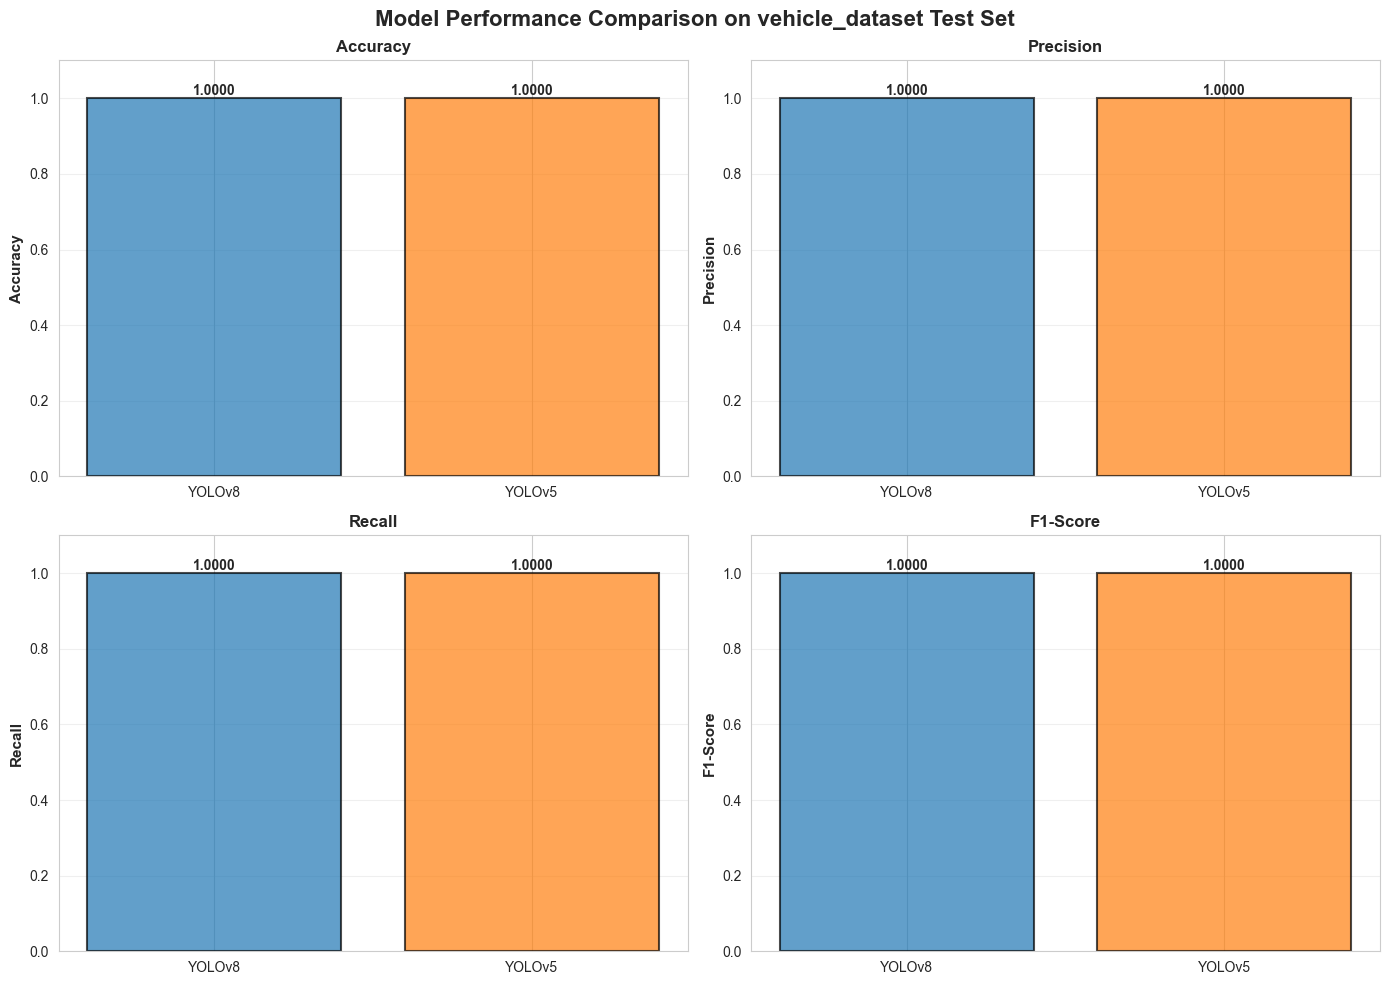

In [24]:
# Compare metrics across models
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison_data = []
for model_name, results in model_results.items():
    metrics = results['metrics']
    comparison_data.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1_Score']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))
print("\n")

# Visualize model comparison
if len(model_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Model Performance Comparison on vehicle_dataset Test Set', 
                 fontsize=16, fontweight='bold')
    
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'][:len(model_results)]
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        values = comparison_df[metric].values
        bars = ax.bar(comparison_df['Model'], values, color=colors, 
                     alpha=0.7, edgecolor='black', linewidth=1.5)
        
        ax.set_ylabel(metric, fontsize=11, fontweight='bold')
        ax.set_ylim([0, 1.1])
        ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


## 14. Summary: Evaluation Results

The cells above evaluate your trained YOLOv8 and YOLOv5 models on the real test dataset located in:
- **Test images**: `vehicle_dataset/images/test/`
- **Ground truth labels**: `vehicle_dataset/labels/test/`

### What the Evaluation Does:

1. **Loads ground truth**: Reads YOLO-format label files to determine which images contain vehicles
2. **Runs inference**: Uses each trained model to make predictions on all test images
3. **Calculates metrics**: Computes Accuracy, Precision, Recall, and F1-Score
4. **Visualizes results**: Displays confusion matrices and comparison charts

### Interpreting Your Results:

- **Accuracy**: Overall correctness across all predictions
- **Precision**: Of the vehicles the model detected, how many were really there (fewer false alarms = higher precision)
- **Recall**: Of all actual vehicles in the dataset, how many did the model find (missing vehicles = lower recall)
- **F1-Score**: Balanced measure combining precision and recall

### Next Steps:

- If Recall is low: Model is missing many vehicles (increase confidence threshold or improve model)
- If Precision is low: Model has too many false alarms (increase confidence threshold)
- If both are low: Model may need retraining or more data
